# Figure showing isobath-adjusted temperature transects through the four DSW regions

In [1]:
import xarray as xr
import numpy as np
import gsw
import intake
from access_nri_intake.source.builders import AccessOm2Builder
import matplotlib.pyplot as plt
import cmocean as cmo

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40309,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45783,Total threads: 1
Dashboard: /proxy/37253/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:38555,


### Define experiment paths. 

In [ ]:
## EXPERIMENTS ## -----------

# DSW_control             =   SFCcon          =  control           -   [ Original control, surface MW ]
# DSW_control_sofia       =   SFCssp126       =  control_ssp126    -   [ Surface MW + SSP1.2‑6 MW anomaly ] 
# DSW_control_antwater    =   SFCantw         =  control_antwater  -   [ Surface MW + Antwater MW anomaly ] 

# Basal                   =   -- not using ??
# Basal_sofia             =   -- not using ??
# Basal_LH_Brine          =   BASAL_LHcon     =  BGB               -   [ Basal MW + LH removal ]
# Basal_LH_Brine_antwater =   BASAL_LHantw    =  BGB_antwater      -   [ Basal MW + LH removal + Antwater MW anomaly ] 
# Basal_LH_Brine_sofia    =   BASAL_LHssp126  =  BGB_ssp126        -   [ Basal MW + LH removal + SSP1.2‑6 MW anomaly ]

# DSW_control_LH          =   SFC_LHcon       =  control_gade      -   [Surface MW + LH removal]
# DSW_control_LH_antwater =   SFC_LH_antw     =  control_gade_antwater  - [ Surface MW + LH removal + Antwater MW anomaly ] 
# DSW_control_antwater_LH =   SFC_Antw_LH     =  control_antwater_gade  -  [ Surface MW + Antwater MW anomaly w/ LH removal ]



## ANOMALIES ## -----------

# SFCantw anomaly         =   control_antwater - control            (SFCantw - SFCcon)
# SFC_LH_antw anomaly     =   control_gade_antwater - control_gade  (SFC_LH_antw - SFC_LHcon )
# SFC_Antw_LH  anomaly    =   control_antwater_gade - control       (SFC_Antw_LH - SFCcon)       *** ?? why ?? ****
# BASAL_LHantw anomaly    =   BGB_antwater - BGB                    (BASAL_LHantw - BASAL_LHcon)


In [5]:
# add experiments to my own intake:

# - Original Control:
path_SFC_con = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - Basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BASAL_LH_con = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'

### SOFIA meltwater perturbation expts:
# - control:
path_SFC_ssp126 = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BASAL_LH_ssp126 = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_SFC_antw = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater"

path_BASAL_LH_antw = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_antwater"

# new control runs with Gade line:
path_SFC_LH_con = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade"
path_SFC_LH_antw = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade_sofia_antwater"
path_SFC_antw_LH = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater_Gade"

### Make datastore. 

In [10]:
%%time
builder = AccessOm2Builder(path=path_SFC_con).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_control", 
             description="Datastore for ACCESS-OM2 ryf9091 DSW control",
            )

builder = AccessOm2Builder(path=path_BASAL_LH_brine).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_control",
             description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
            )

builder = AccessOm2Builder(path=path_SFC_ssp126).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_ssp126",
             description="Datastore for ACCESS-OM2 ryf9091 SOFIA control (mbath21)",
            )

builder = AccessOm2Builder(path=path_BASAL_LH_ssp126 ).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_ssp126", 
             description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal_LH_Brine rep.",
            )

builder = AccessOm2Builder(path=path_SFC_antw ).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_antwater", 
             description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater control (mbath21)",
            )

builder = AccessOm2Builder(path=path_BASAL_LH_antw).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_antwater", 
             description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater Basal_LH_Brine",
            )

builder = AccessOm2Builder(path=path_SFC_LH_con).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_LH_control", 
             description="Datastore for ACCESS-OM2 ryf9091 control, applying Gade line (all runoff)",
            )

builder = AccessOm2Builder(path=path_SFC_LH_antw).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_LH_antwater", 
             description="Datastore for ACCESS-OM2 ryf9091 control + Antwater applying Gade line (all runoff)",
            )

builder = AccessOm2Builder(path=path_SFC_antw_LH).build()
builder.save(name="../../../g/data/e14/hd4873/database/basal_colab/SFC_antwater_LH", 
             description="Datastore for ACCESS-OM2 ryf9091 control, applying Gade line only for Antwater anomaly",
            )

Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/SFC_control.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_control.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/SFC_ssp126.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_ssp126.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/SFC_antwater.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_antwater.json
Successfully wrote ESM catalog json file to: file:///home/561/hd4873/../../../g/data/e14/hd4873/database/basal_colab/SFC_LH_control.json
Successfully wrote ESM catalog json file to:

### Load datastore

In [3]:
# Control / SFC_CON
cat = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BSL_LH_con = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] 
)

cat_SFC_ssp126 = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_ssp126.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important 
)

cat_BSL_ssp126 = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_ssp126.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_SFC_antw = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BSL_antwater = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/BASAL_LH_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_SFC_LH_con = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_LH_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_SFC_LH_antw = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_LH_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_SFC_antw_LH = intake.open_esm_datastore(
    "../../../g/data/e14/hd4873/database/basal_colab/SFC_antwater_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

### Load temperature and bathymetry data for required experiments

In [4]:
# Make sure these match the available restarts:
start_time = '1917-01-01'
end_time = '1919-12-31'
time_slice = slice(start_time, end_time)
lat_slice  = slice(-80,-59)

# outpath = '/g/data/e14/fbd581/Basal_Pedro_project/SWMT/'

In [5]:
def get_temperature(catalog):

    temp = catalog.search(variable="temp", frequency="1mon").to_dask(decode_timedelta=True)
    temp = temp.sel(time=time_slice, yt_ocean=lat_slice) - 273.15

    # calculate annual mean temperature
    temp = temp.mean('time')

    return temp


def get_bathymetry(catalog):
    ht = catalog.search(variable="ht",).to_dask(decode_timedelta=True)
    ht = ht.sel(yt_ocean=lat_slice)
    return ht['ht']

In [6]:
# Control experiments
SFCcon = get_temperature(cat)
SFC_LHcon = get_temperature(cat_SFC_LH_con )
BASAL_LHcon = get_temperature(cat_BSL_LH_con)

# perturbation experiments
SFCantw = get_temperature(cat_SFC_antw)
SFC_LH_antw = get_temperature(cat_SFC_LH_antw)
SFC_antw_LH = get_temperature(cat_SFC_antw_LH )
BASAL_LHantw = get_temperature(cat_BSL_antwater)

In [7]:
%%time
# Control experiments
SFCcon = SFCcon.load()
SFC_LHcon = SFC_LHcon.load()
BASAL_LHcon = BASAL_LHcon.load()

# perturbation experiments
SFCantw = SFCantw.load()
SFC_LH_antw = SFC_LH_antw.load()
SFC_antw_LH = SFC_antw_LH.load()
BASAL_LHantw = BASAL_LHantw.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.21 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.05 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/cli

CPU times: user 1min 49s, sys: 52.9 s, total: 2min 42s
Wall time: 3min 19s


Bathymetry

In [8]:
ht = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc')
ht = ht.sel(yt_ocean=lat_slice)
ht = ht['ht'].load()

Define functions to select regions and adjust latitude to align at 1000m isobath. 

In [9]:
def get_region(ds, ht, lon_slice):
    return ds.sel(xt_ocean = lon_slice), ht.sel(xt_ocean = lon_slice)

def isobath_latitudes():

    basins=xr.open_dataset('/scratch/jk72/jn8053/Antarctic_shelf_basins.nc')['basins']
    shelf = xr.where(basins!=100, 1, np.nan).where(~np.isnan(basins))
    shelf = shelf.sel(xt_ocean=lon_slice)

    shelf_edge = shelf.sel(yt_ocean=slice(None,None,-1)).cumsum('yt_ocean', skipna=True).where(shelf.sel(yt_ocean=slice(None,None,-1)).cumsum('yt_ocean', skipna=True)!=0)
    slope_idx = np.empty(len(shelf_edge['xt_ocean']))*np.nan
    for x in range(len(shelf_edge['xt_ocean'])):
        if len(np.where(shelf_edge[:,x]==np.nanmin(shelf_edge[:,x]))[0])!=0:
            slope_idx[x] = np.where(shelf_edge[:,x]==np.nanmin(shelf_edge[:,x]))[0][0]

    y_idx = slope_idx*np.nan
    for x in range(len(shelf_edge['xt_ocean'])):
        if ~np.isnan(slope_idx[x]):
            y_idx[x] = shelf_edge['yt_ocean'][int(slope_idx[x])] 
    latitudes = xr.DataArray(y_idx, dims=['xt_ocean'], coords={'xt_ocean':shelf['xt_ocean']})
    latitudes = latitudes.interpolate_na('xt_ocean', method='nearest')       

    return latitudes
        
def adjust_latitudes_to_isobath(ds, isobath_latitude):

    iso_lat_coord = np.zeros_like(ds['temp'])
    for j in range(ds.xt_ocean.size):
        iso_lat_coord[:, j] = ds.yt_ocean - isobath_latitude[j]

    ds_adjusted = ds.copy()
    ds_adjusted = xr.Dataset({"temp": (("lat", "lon"), ds['temp']),
                              "isobath_latitude": (("lat", "lon"), iso_lat_coord),
    },
    coords={"lon": lon}
)
    
    return ds_adjusted

Select region

In [11]:
%%time
lon_slice=slice(60,75)
# lon_slice=slice(170-360, 180-360)

# Control experiments
SFCcon_region, ht_region = get_region(SFCcon, ht, lon_slice)
SFC_LHcon_region, ht_region = get_region(SFC_LHcon, ht, lon_slice)
BASAL_LHcon_region, ht_region = get_region(BASAL_LHcon, ht, lon_slice)

# perturbation experiments
SFCantw_region, ht_region = get_region(SFCantw, ht, lon_slice)
SFC_LH_antw_region, ht_region= get_region(SFC_LH_antw, ht, lon_slice)
SFC_antw_LH_region, ht_region = get_region(SFC_antw_LH, ht, lon_slice)
BASAL_LHantw_region, ht_region = get_region(BASAL_LHantw, ht, lon_slice)

CPU times: user 73.1 ms, sys: 63.3 ms, total: 136 ms
Wall time: 97 ms


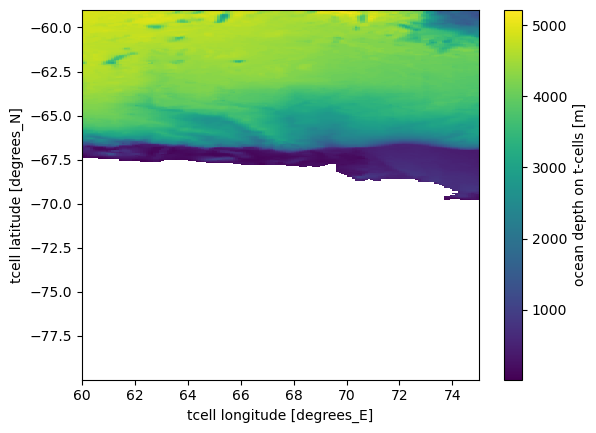

In [12]:
ht_region.plot();

Get adjusted isobath

In [13]:
isobath_latitude = isobath_latitudes()

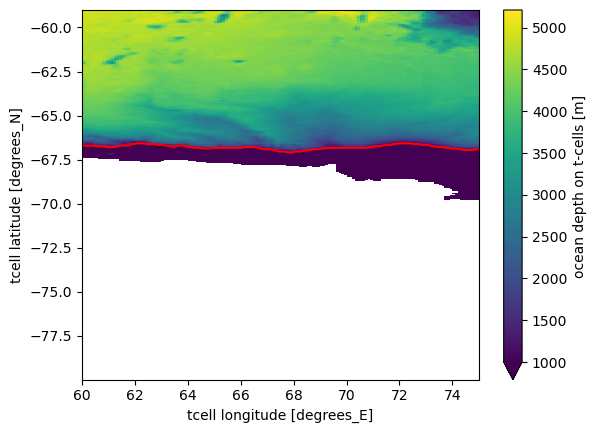

In [14]:
ht_region.plot(vmin=1000, );
plt.plot(ht_region.xt_ocean, isobath_latitude, c='r')
# plt.plot(ht_region.xt_ocean, isobath_latitude_H, c='cyan', ls='--')
# plt.ylim([-70, -64]);

In [15]:
def lat_adjusted_array(ds_region, ht_region):

    adjusted_array = ds_region['temp'].isel(yt_ocean=slice(None, 400)).copy(deep=True)
    new_latitude = np.arange(-200 * 0.04223935, 200 * 0.04223935, 0.04223935)
    adjusted_array = adjusted_array.rename({"yt_ocean": "isobath_relative_lat"})
    adjusted_array['isobath_relative_lat'] =  new_latitude
    adjusted_array[:,:,:] = np.nan

    for i, x in enumerate(ht_region.xt_ocean):
        idx = int(np.where(ht_region.yt_ocean == isobath_latitude[i])[0][0])
        adjusted_array[:,:200,i] = ds_region['temp'].isel(xt_ocean=i)[:, idx-200:idx].values
        adjusted_array[:,200:300,i] = ds_region['temp'].isel(xt_ocean=i)[:, idx:idx+100].values

    return adjusted_array

In [16]:
adjusted_array = SFCcon_region['temp'].isel(yt_ocean=slice(None, 400)).copy(deep=True)
new_latitude = np.arange(-200 * 0.04223935, 200 * 0.04223935, 0.04223935)
adjusted_array = adjusted_array.rename({"yt_ocean": "isobath_relative_lat"})
adjusted_array['isobath_relative_lat'] =  new_latitude
adjusted_array[:,:,:] = np.nan

for i, x in enumerate(ht_region.xt_ocean):
    idx = int(np.where(ht_region.yt_ocean == isobath_latitude[i])[0][0])
    adjusted_array[:,:200,i] = SFCcon_region['temp'].isel(xt_ocean=i)[:, idx-200:idx].values

In [17]:
SFCcon_adjusted = lat_adjusted_array(SFCcon_region, ht_region)
SFC_LHcon_adjusted = lat_adjusted_array(SFC_LHcon_region, ht_region)
BASAL_LHcon_adjusted = lat_adjusted_array(BASAL_LHcon_region, ht_region)

SFCantw_adjusted = lat_adjusted_array(SFCantw_region, ht_region)
SFC_LH_antw_adjusted = lat_adjusted_array(SFC_LH_antw_region, ht_region)
SFC_antw_LH_adjusted = lat_adjusted_array(SFC_antw_LH_region, ht_region)
BASAL_LHantw_adjusted = lat_adjusted_array(BASAL_LHantw_region, ht_region)

### Analysis/Figure

In [18]:
def figure_setup():
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(20,8), sharey=True, sharex=True)
    plt.subplots_adjust(wspace=0.06, hspace=0.16)

    for i, ax in enumerate(axes.flatten()[-4:]):
        ax.set_xlabel('Latitude from 1000m isobath (\u00b0N)')

    for i, ax in enumerate(axes[:,0].flatten()):
        ax.set_ylabel('Depth (km)')

    axes[0,0].set_title('SFC$_{CON}$')
    axes[0,1].set_title('SFC$_{CON}$')
    axes[0,2].set_title('SFC_LH$_{CON}$')
    axes[0,3].set_title('BASAL_LH$_{CON}$')
    
    axes[1,0].set_title('SFC$_{Antw}$ - SFC$_{CON}$')
    axes[1,1].set_title('SFC$_{Antw}$_$_{LH}$ - SFC$_{CON}$')
    axes[1,2].set_title('SFC_LH$_{Antw}$ - SFC_LH$_{CON}$')
    axes[1,3].set_title('BASAL_LH$_{antw}$ - BASAL_LH$_{CON}$')   

    return fig, axes

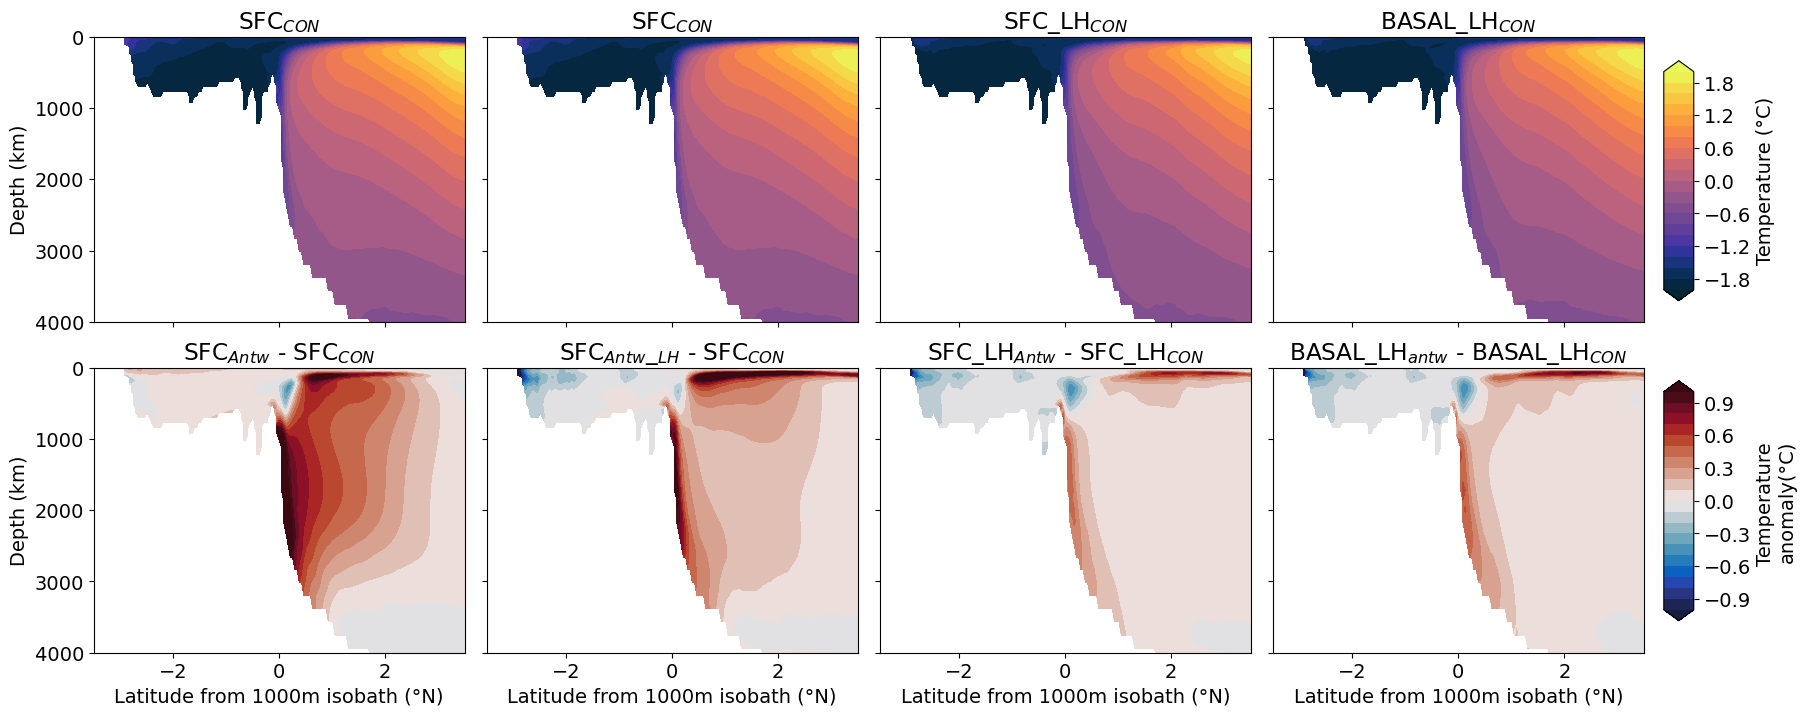

In [21]:
fig, axes = figure_setup()

z, lat = SFCcon_adjusted.st_ocean, SFCcon_adjusted.isobath_relative_lat

cb = axes[0,0].contourf(lat, z, SFCcon_adjusted.mean('xt_ocean'),
                  cmap=cmo.cm.thermal, levels=np.arange(-2, 2.01, 0.2), extend='both')
axes[0,1].contourf(lat, z, SFCcon_adjusted.mean('xt_ocean'),
                  cmap=cmo.cm.thermal, levels=np.arange(-2, 2.01, 0.2))
axes[0,2].contourf(lat, z, SFC_LHcon_adjusted.mean('xt_ocean'),
                  cmap=cmo.cm.thermal, levels=np.arange(-2, 2.01, 0.2))
axes[0,3].contourf(lat, z, BASAL_LHcon_adjusted.mean('xt_ocean'),
                  cmap=cmo.cm.thermal, levels=np.arange(-2, 2.01, 0.2))
cax = fig.add_axes([0.91, 0.55, 0.015, 0.3])
cbar = fig.colorbar(cb, cax=cax, orientation='vertical', label='Temperature (\u00b0C)')


cb = axes[1,0].contourf(lat, z, (SFCantw_adjusted - SFCcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')
axes[1,1].contourf(lat, z, (SFC_antw_LH_adjusted - SFCcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')
axes[1,2].contourf(lat, z, (SFC_LH_antw_adjusted - SFC_LHcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')
axes[1,3].contourf(lat, z, (BASAL_LHantw_adjusted - BASAL_LHcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')
cax = fig.add_axes([0.91, 0.15, 0.015, 0.3])
cbar = fig.colorbar(cb, cax=cax, orientation='vertical', label='Temperature \nanomaly(\u00b0C)')


axes[0,0].set_ylim([4000, 0])
axes[0,0].set_xlim([-3.5, 3.5])

fig.savefig('/g/data/e14/hd4873/basal_colab/figures/temp_transects_60E-75E.jpg', dpi=300, bbox_inches='tight')

plt.show()

In [45]:
def figure_setup():
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(20,5), sharey=True, sharex=True)
    plt.subplots_adjust(wspace=0.1, hspace=0.16)

    for i, ax in enumerate(axes.flatten()[-4:]):
        ax.set_xlabel('Latitude from 1000m isobath (\u00b0N)')

    for i, ax in enumerate(axes[:].flatten()):
        ax.set_ylabel('Depth (km)')

    axes[0].set_title('SFC$_{CON}$')
    axes[1].set_title('SFC_LH$_{CON}$ - SFC$_{CON}$')
    axes[2].set_title('BASAL_LH$_{CON}$ - SFC$_{CON}$')

    return fig, axes

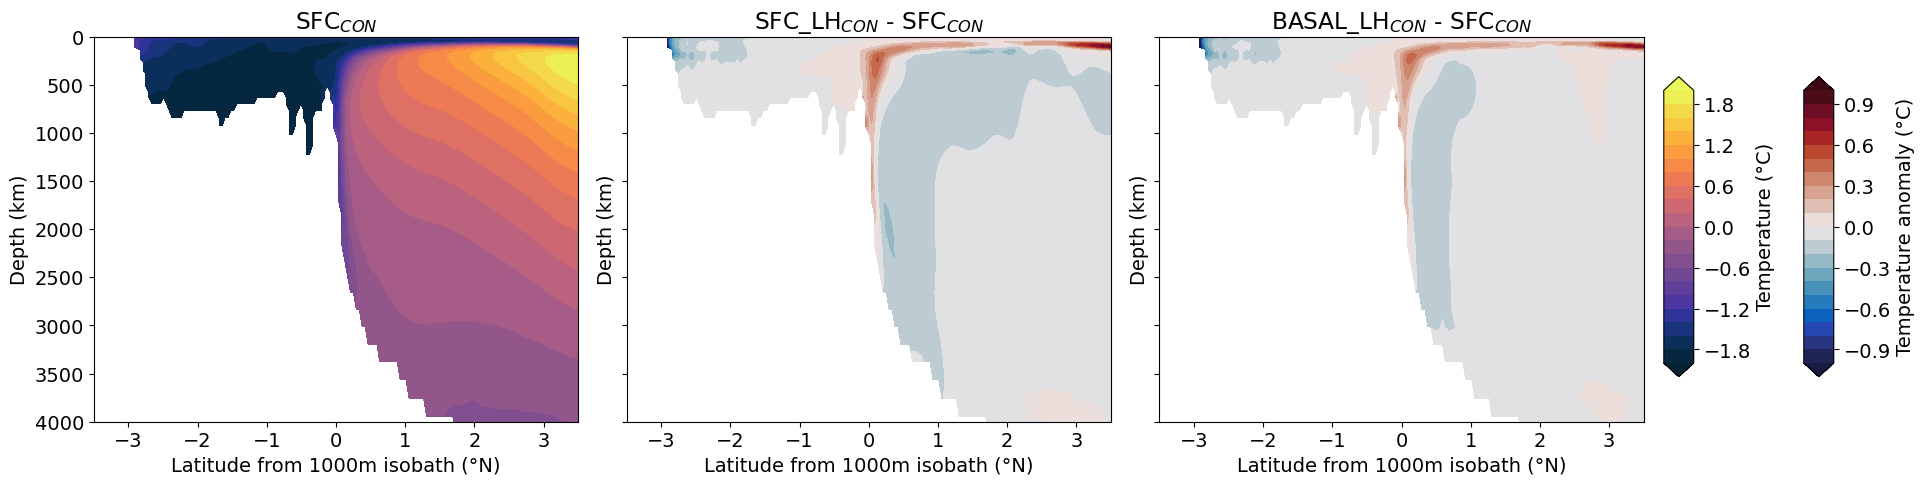

In [46]:
fig, axes = figure_setup()

z, lat = SFCcon_adjusted.st_ocean, SFCcon_adjusted.isobath_relative_lat


cb = axes[0].contourf(lat, z, SFCcon_adjusted.mean('xt_ocean'),
                  cmap=cmo.cm.thermal, levels=np.arange(-2, 2.01, 0.2), extend='both')

cax = fig.add_axes([0.91, 0.2, 0.015, 0.6])
cbar = fig.colorbar(cb, cax=cax, orientation='vertical', label='Temperature (\u00b0C)')

cb = axes[1].contourf(lat, z, (SFC_LHcon_adjusted - SFCcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')

cb = axes[2].contourf(lat, z, (BASAL_LHcon_adjusted - SFCcon_adjusted).mean('xt_ocean'),
                  cmap=cmo.cm.balance, levels=np.arange(-1, 1.01, 0.1), extend='both')

cax = fig.add_axes([0.98, 0.2, 0.015, 0.6])
cbar = fig.colorbar(cb, cax=cax, orientation='vertical', label='Temperature anomaly (\u00b0C)')

axes[0].set_ylim([4000, 0])
axes[0].set_xlim([-3.5, 3.5])

fig.savefig('/g/data/e14/hd4873/basal_colab/figures/temp_transects_control_60E-75E.jpg', dpi=300, bbox_inches='tight')

plt.show()